# Agent Comparison Study

Compares four agents on the 10 held-out test profiles (5 episodes each, 20 steps/episode):
- **PPO (RL Agent)** — trained adaptive agent 
- **Random** — uniform random action selection 
- **Rule-Based Adaptive** — heuristic difficulty scaling
- **Fixed Curriculum** — static scenario progression


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

# Allow imports from backend root
ROOT = Path("../").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

matplotlib.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="muted")

FIGURES_DIR = ROOT / "data/evaluation/comparison/figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Agent display order and colours
AGENT_ORDER = ["PPO (RL Agent)", "Rule-Based Adaptive", "Fixed Curriculum", "Random"]
AGENT_PALETTE = {
    "PPO (RL Agent)":       "#2196F3",
    "Rule-Based Adaptive":  "#FF9800",
    "Fixed Curriculum":     "#4CAF50",
    "Random":               "#9E9E9E",
}

SEVERITY_LABELS = {1: "Mild", 2: "Moderate", 3: "Severe"}

print("Libraries loaded.")

Libraries loaded.


## 1  Load Data

In [2]:
DATA_DIR = ROOT / "data/evaluation/comparison"

df = pd.read_csv(DATA_DIR / "results_combined.csv")
df["severity_label"] = df["severity"].map(SEVERITY_LABELS)

print(f"Rows: {len(df):,}")
print(f"Agents: {df['agent'].unique().tolist()}")
print(f"Profiles: {df['user_id'].nunique()} test users")
print(f"\nSeverity distribution (unique profiles):")
print(df.drop_duplicates('user_id')[['severity','severity_label']].value_counts().sort_index())
df.head()

Rows: 4,000
Agents: ['PPO (RL Agent)', 'Random', 'Rule-Based Adaptive', 'Fixed Curriculum']
Profiles: 10 test users

Severity distribution (unique profiles):
severity  severity_label
1         Mild              2
2         Moderate          5
3         Severe            3
Name: count, dtype: int64


,agent,user_id,split,severity,episode,step,action_idx,scenario_type,difficulty,task_completed,reward,frustration,engagement,confidence,cooperation,fairness,num_retries,completion_time,severity_label
0,PPO (RL Agent),user_040,test,1,0,0,96,emotion_recognition,1,True,0.932800,0.0,1.000000,0.571999,0.51,0.5,0,15.724174,Mild
1,PPO (RL Agent),user_040,test,1,0,1,17,sharing,1,True,0.794307,0.0,0.586340,0.476030,0.52,0.5,0,30.193733,Mild
2,PPO (RL Agent),user_040,test,1,0,2,96,emotion_recognition,1,False,0.341000,0.7,1.000000,0.000000,0.52,0.5,0,31.258180,Mild
3,PPO (RL Agent),user_040,test,1,0,3,96,emotion_recognition,1,True,0.928048,0.0,1.000000,0.540321,0.53,0.5,0,30.466064,Mild
4,PPO (RL Agent),user_040,test,1,0,4,17,sharing,1,True,0.777029,0.0,0.525346,0.482837,0.54,0.5,0,42.740691,Mild


## 2  Summary Statistics Table

In [3]:
# Episode-level aggregation (mean per episode, then across episodes)
ep = (
    df.groupby(["agent", "user_id", "episode"])
    .agg(
        episode_reward=("reward", "sum"),
        task_rate=("task_completed", "mean"),
        mean_frustration=("frustration", "mean"),
        mean_engagement=("engagement", "mean"),
        mean_confidence=("confidence", "mean"),
    )
    .reset_index()
)

def ci95(x):
    """Bootstrap 95% CI half-width."""
    n = len(x)
    if n < 2:
        return 0.0
    boots = [np.mean(np.random.choice(x, size=n, replace=True)) for _ in range(2000)]
    return float(np.percentile(boots, 97.5) - np.percentile(boots, 2.5)) / 2

np.random.seed(42)
summary = (
    ep.groupby("agent")
    .agg(
        mean_episode_reward=("episode_reward", "mean"),
        ci_reward=("episode_reward", ci95),
        mean_task_rate=("task_rate", "mean"),
        ci_task_rate=("task_rate", ci95),
        mean_frustration=("mean_frustration", "mean"),
        mean_engagement=("mean_engagement", "mean"),
        mean_confidence=("mean_confidence", "mean"),
    )
    .reindex(AGENT_ORDER)
    .round(4)
)

print("=== Summary Table ===")
print(summary.to_string())
summary.to_csv(DATA_DIR / "summary_table_episodes.csv")

=== Summary Table ===
                     mean_episode_reward  ci_reward  mean_task_rate  ci_task_rate  mean_frustration  mean_engagement  mean_confidence
agent                                                                                                                                
PPO (RL Agent)                   13.7517     0.4946           0.647        0.0475            0.1734           0.8863           0.2817
Rule-Based Adaptive              12.3287     0.4172           0.485        0.0390            0.2212           0.9159           0.2291
Fixed Curriculum                 12.7876     0.5482           0.538        0.0540            0.2143           0.9093           0.2466
Random                           11.9964     0.4154           0.464        0.0435            0.2344           0.8978           0.2239


## 3  Primary Figure — Mean Episode Reward ± 95% CI

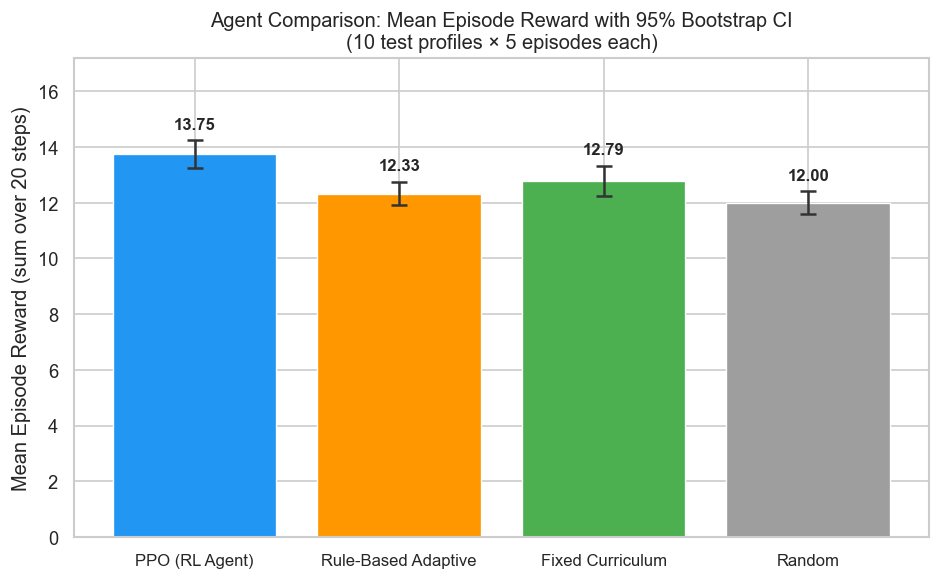

Saved agent_comparison_bar.png/.pdf


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

means  = summary["mean_episode_reward"].values
cis    = summary["ci_reward"].values
labels = summary.index.tolist()
colors = [AGENT_PALETTE[a] for a in labels]

bars = ax.bar(labels, means, color=colors, edgecolor="white", linewidth=0.8)
ax.errorbar(
    x=range(len(labels)), y=means,
    yerr=cis, fmt="none",
    color="#333", capsize=5, linewidth=1.5, capthick=1.5
)

# Annotate bars
for bar, mean_val, ci_val in zip(bars, means, cis):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        mean_val + ci_val + 0.3,
        f"{mean_val:.2f}",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylabel("Mean Episode Reward (sum over 20 steps)")
ax.set_title("Agent Comparison: Mean Episode Reward with 95% Bootstrap CI\n(10 test profiles × 5 episodes each)")
ax.set_ylim(0, max(means) * 1.25)
ax.tick_params(axis="x", labelsize=10)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "agent_comparison_bar.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "agent_comparison_bar.pdf", bbox_inches="tight")
plt.show()
print("Saved agent_comparison_bar.png/.pdf")

## 4  Statistical Tests — PPO vs Each Baseline

In [5]:
def cohens_d(a, b):
    """Cohen's d effect size."""
    pooled_std = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0.0

def effect_label(d):
    d = abs(d)
    if d >= 0.8: return "large"
    if d >= 0.5: return "medium"
    if d >= 0.2: return "small"
    return "negligible"

ppo_rewards = ep[ep["agent"] == "PPO (RL Agent)"]["episode_reward"].values
baselines = ["Rule-Based Adaptive", "Fixed Curriculum", "Random"]

print(f"{'Comparison':<35} {'U-stat':>8} {'p-value':>10} {'d':>8} {'effect':>12}")
print("-" * 75)
stat_rows = []
for baseline in baselines:
    base_rewards = ep[ep["agent"] == baseline]["episode_reward"].values
    u_stat, p_val = stats.mannwhitneyu(ppo_rewards, base_rewards, alternative="greater")
    d = cohens_d(ppo_rewards, base_rewards)
    label = f"PPO vs {baseline}"
    print(f"{label:<35} {u_stat:>8.0f} {p_val:>10.4f} {d:>8.3f} {effect_label(d):>12}")
    stat_rows.append({
        "comparison": label,
        "U_statistic": u_stat,
        "p_value": p_val,
        "cohens_d": round(d, 4),
        "effect_size": effect_label(d),
        "significant_p05": p_val < 0.05,
    })

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(DATA_DIR / "statistical_tests.csv", index=False)
print("\nSaved statistical_tests.csv")

Comparison                            U-stat    p-value        d       effect
---------------------------------------------------------------------------
PPO vs Rule-Based Adaptive              1820     0.0000    0.857        large
PPO vs Fixed Curriculum                 1600     0.0080    0.501       medium
PPO vs Random                           1936     0.0000    1.046        large

Saved statistical_tests.csv


## 5  Severity Subgroup Analysis

/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/3543219784.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)
/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/3543219784.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)
/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/3543219784.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)


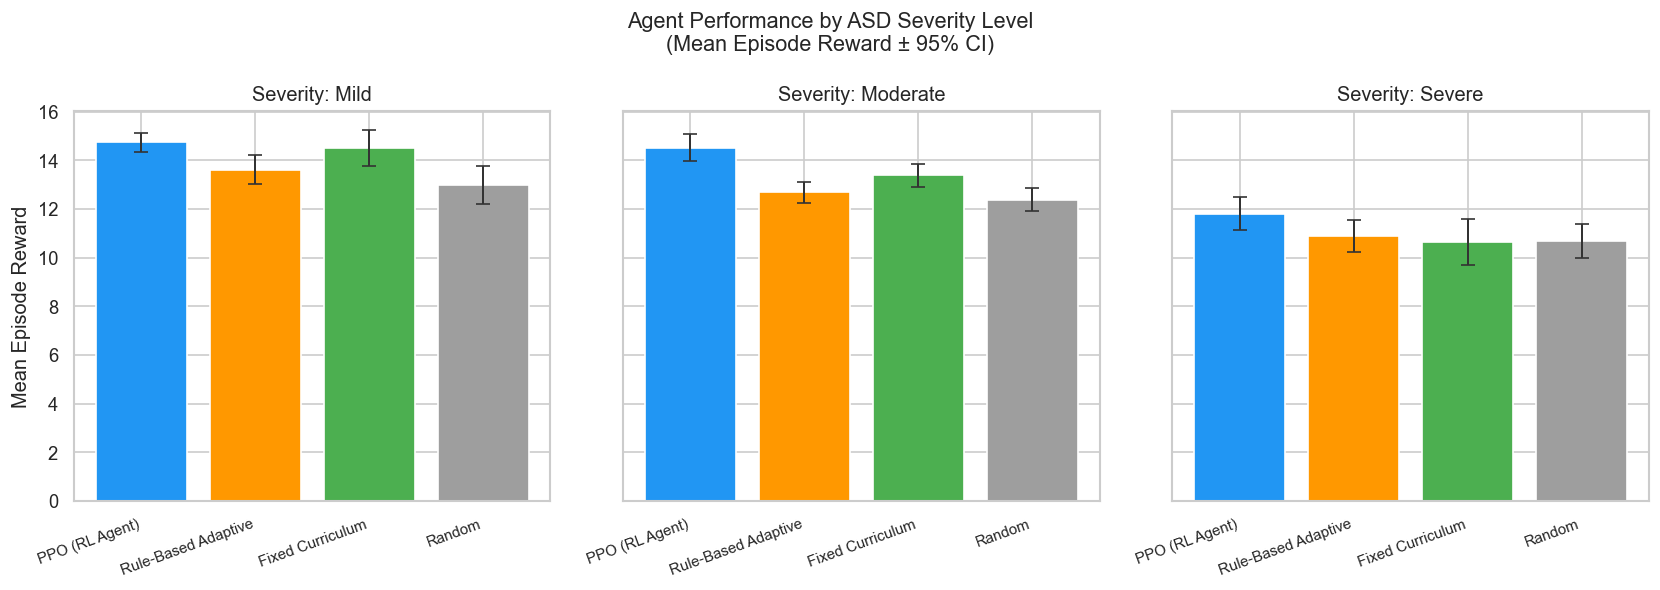

Saved severity_breakdown.png/.pdf

PPO advantage over Rule-Based Adaptive by severity:
  Mild      : PPO=14.745  Rule-Based=13.614  Δ=+1.131
  Moderate  : PPO=14.521  Rule-Based=12.678  Δ=+1.843
  Severe    : PPO=11.808  Rule-Based=10.889  Δ=+0.919


In [6]:
# Add severity to episode-level data
sev_map = df.drop_duplicates("user_id").set_index("user_id")["severity"].to_dict()
ep["severity"] = ep["user_id"].map(sev_map)
ep["severity_label"] = ep["severity"].map(SEVERITY_LABELS)

sev_summary = (
    ep.groupby(["agent", "severity_label"])
    .agg(mean_reward=("episode_reward", "mean"), se_reward=("episode_reward", "sem"))
    .reset_index()
)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, sev_label in zip(axes, ["Mild", "Moderate", "Severe"]):
    sub = sev_summary[sev_summary["severity_label"] == sev_label].set_index("agent").reindex(AGENT_ORDER)
    colors = [AGENT_PALETTE[a] for a in sub.index]
    bars = ax.bar(sub.index, sub["mean_reward"], color=colors, edgecolor="white")
    ax.errorbar(
        x=range(len(sub)), y=sub["mean_reward"],
        yerr=sub["se_reward"] * 1.96,
        fmt="none", color="#333", capsize=4, linewidth=1.2
    )
    ax.set_title(f"Severity: {sev_label}")
    ax.set_ylabel("Mean Episode Reward" if sev_label == "Mild" else "")
    ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)

fig.suptitle("Agent Performance by ASD Severity Level\n(Mean Episode Reward ± 95% CI)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "severity_breakdown.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "severity_breakdown.pdf", bbox_inches="tight")
plt.show()
print("Saved severity_breakdown.png/.pdf")

# Print advantage of PPO over rule-based per severity
print("\nPPO advantage over Rule-Based Adaptive by severity:")
for sev in ["Mild", "Moderate", "Severe"]:
    ppo_r = ep[(ep["agent"]=="PPO (RL Agent)") & (ep["severity_label"]==sev)]["episode_reward"].mean()
    rb_r  = ep[(ep["agent"]=="Rule-Based Adaptive") & (ep["severity_label"]==sev)]["episode_reward"].mean()
    print(f"  {sev:10s}: PPO={ppo_r:.3f}  Rule-Based={rb_r:.3f}  Δ={ppo_r-rb_r:+.3f}")

## 6  Learning Curves — Cumulative Reward Over Steps

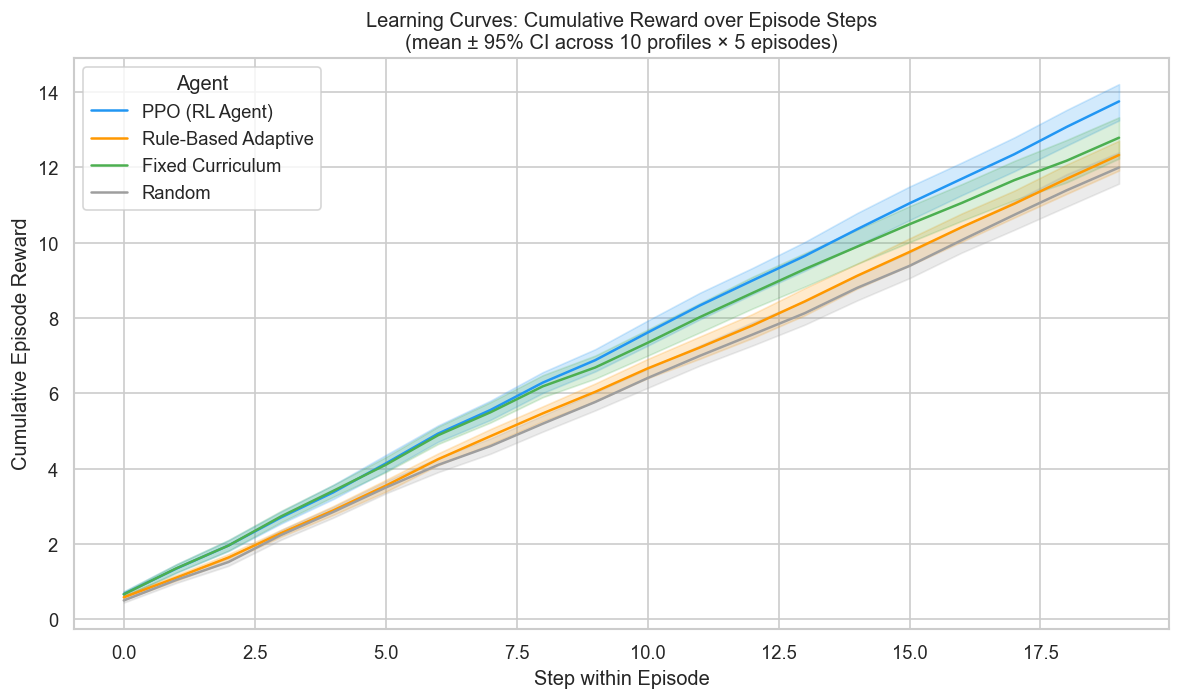

Saved learning_curves.png/.pdf


In [7]:
# Cumulative reward within episode, averaged across all episodes and profiles
df_sorted = df.sort_values(["agent", "user_id", "episode", "step"])
df_sorted["cum_reward"] = df_sorted.groupby(["agent", "user_id", "episode"])["reward"].cumsum()

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(
    data=df_sorted,
    x="step", y="cum_reward",
    hue="agent", hue_order=AGENT_ORDER,
    palette=AGENT_PALETTE,
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_xlabel("Step within Episode")
ax.set_ylabel("Cumulative Episode Reward")
ax.set_title("Learning Curves: Cumulative Reward over Episode Steps\n(mean ± 95% CI across 10 profiles × 5 episodes)")
ax.legend(title="Agent", loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "learning_curves.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "learning_curves.pdf", bbox_inches="tight")
plt.show()
print("Saved learning_curves.png/.pdf")

## 7  Difficulty Trajectory — How Each Agent Adapts

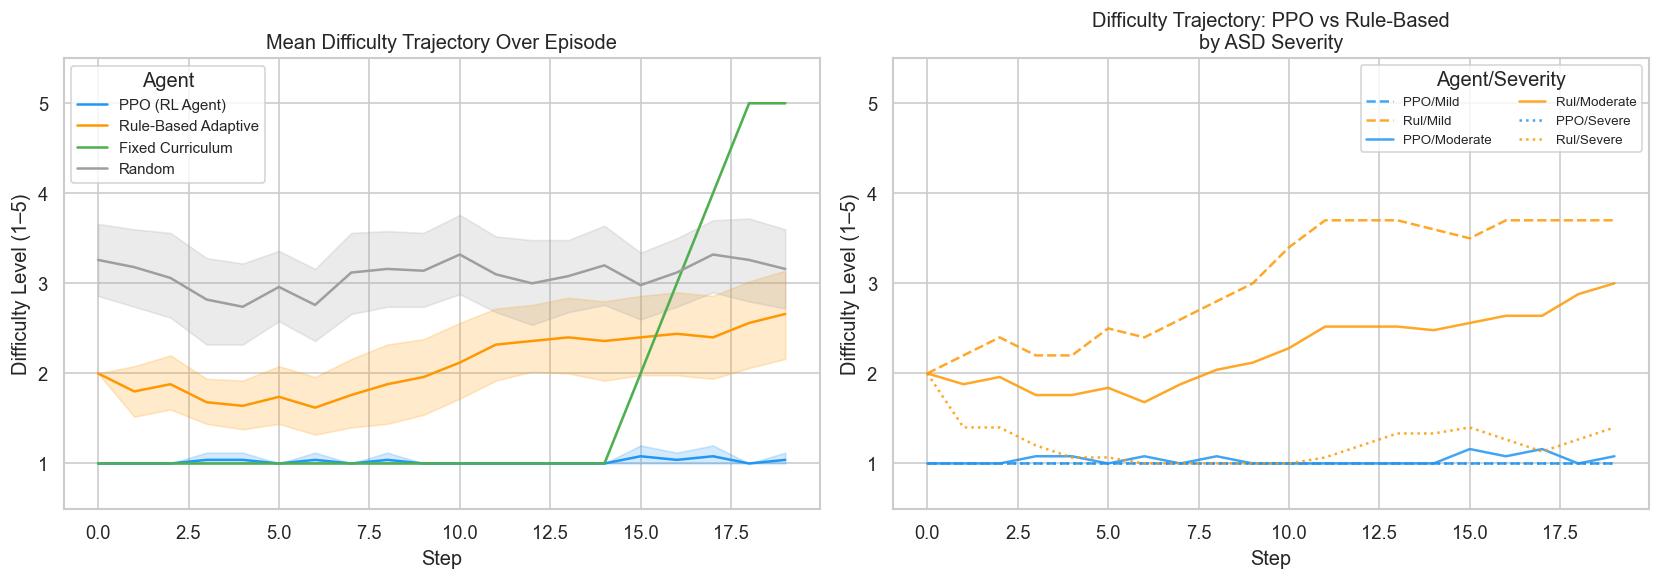

Saved difficulty_trajectories.png/.pdf


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: overall difficulty trajectory
ax = axes[0]
sns.lineplot(
    data=df,
    x="step", y="difficulty",
    hue="agent", hue_order=AGENT_ORDER,
    palette=AGENT_PALETTE,
    errorbar=("ci", 95),
    ax=ax,
)
ax.set_xlabel("Step")
ax.set_ylabel("Difficulty Level (1–5)")
ax.set_title("Mean Difficulty Trajectory Over Episode")
ax.set_ylim(0.5, 5.5)
ax.legend(title="Agent", fontsize=9)

# Panel B: difficulty trajectory by severity for PPO vs Rule-Based
ax = axes[1]
focus = df[df["agent"].isin(["PPO (RL Agent)", "Rule-Based Adaptive"])].copy()
focus["severity_label"] = focus["severity"].map(SEVERITY_LABELS)

for severity_label, style in [("Mild", "--"), ("Moderate", "-"), ("Severe", ":")]:
    for agent, color in [("PPO (RL Agent)", "#2196F3"), ("Rule-Based Adaptive", "#FF9800")]:
        sub = focus[(focus["agent"]==agent) & (focus["severity_label"]==severity_label)]
        mean_diff = sub.groupby("step")["difficulty"].mean()
        ax.plot(
            mean_diff.index, mean_diff.values,
            linestyle=style, color=color, alpha=0.85,
            label=f"{agent[:3]}/{severity_label}"
        )

ax.set_xlabel("Step")
ax.set_ylabel("Difficulty Level (1–5)")
ax.set_title("Difficulty Trajectory: PPO vs Rule-Based\nby ASD Severity")
ax.set_ylim(0.5, 5.5)
ax.legend(title="Agent/Severity", fontsize=8, ncol=2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "difficulty_trajectories.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "difficulty_trajectories.pdf", bbox_inches="tight")
plt.show()
print("Saved difficulty_trajectories.png/.pdf")

## 8  Frustration & Engagement — Emotional Outcomes

/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/1987475838.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(AGENT_ORDER, rotation=20, ha="right", fontsize=9)
/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/1987475838.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(AGENT_ORDER, rotation=20, ha="right", fontsize=9)
/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/1987475838.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(AGENT_ORDER, rotation=20, ha="right", fontsize=9)


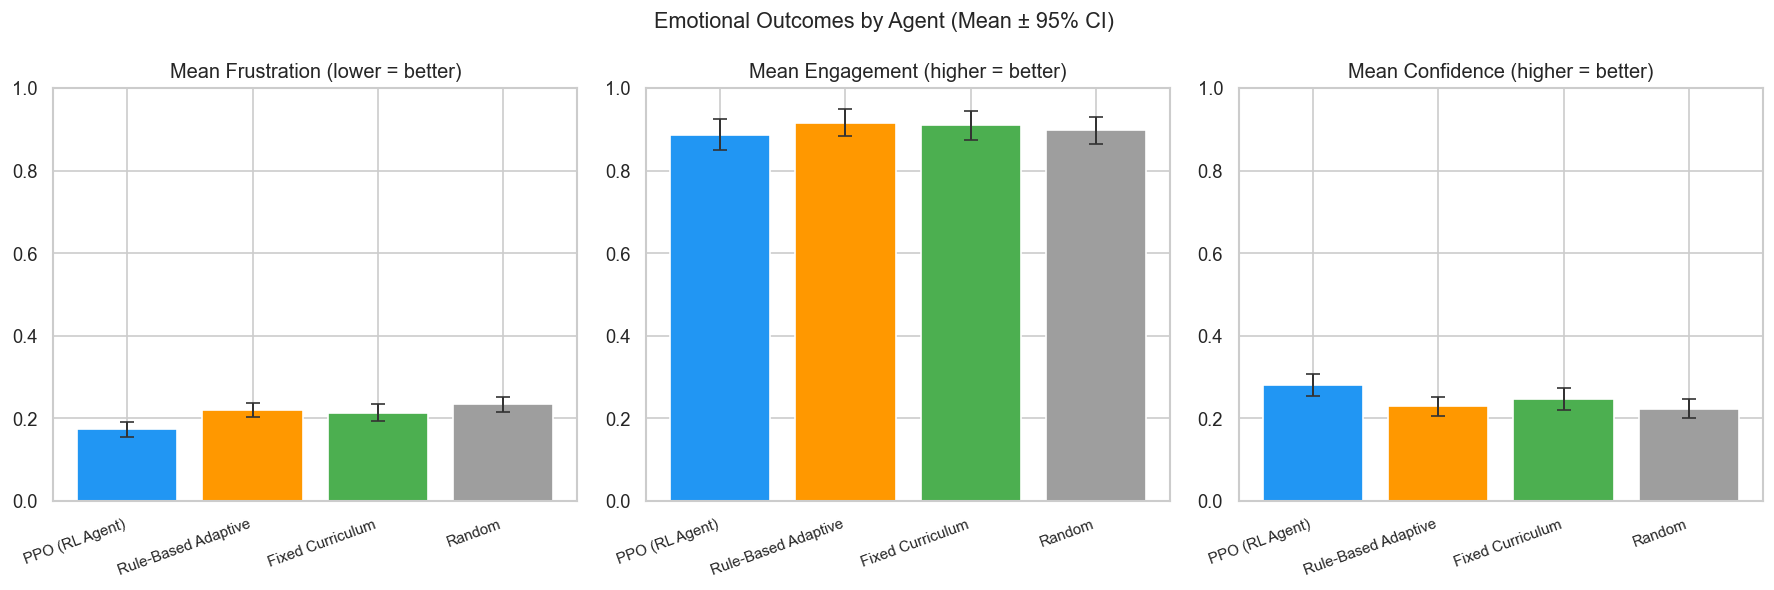

Saved frustration_engagement.png/.pdf


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ("mean_frustration", "Mean Frustration (lower = better)"),
    ("mean_engagement",  "Mean Engagement (higher = better)"),
    ("mean_confidence",  "Mean Confidence (higher = better)"),
]

for ax, (col, ylabel) in zip(axes, metrics):
    ag_means = ep.groupby("agent")[col].mean().reindex(AGENT_ORDER)
    ag_cis   = ep.groupby("agent")[col].sem().reindex(AGENT_ORDER) * 1.96
    colors   = [AGENT_PALETTE[a] for a in AGENT_ORDER]

    ax.bar(AGENT_ORDER, ag_means, color=colors, edgecolor="white")
    ax.errorbar(
        x=range(len(AGENT_ORDER)), y=ag_means,
        yerr=ag_cis,
        fmt="none", color="#333", capsize=4, linewidth=1.2
    )
    ax.set_title(ylabel)
    ax.set_xticklabels(AGENT_ORDER, rotation=20, ha="right", fontsize=9)
    ax.set_ylim(0, 1.0)

fig.suptitle("Emotional Outcomes by Agent (Mean ± 95% CI)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "frustration_engagement.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "frustration_engagement.pdf", bbox_inches="tight")
plt.show()
print("Saved frustration_engagement.png/.pdf")

## 9  Action Diversity — Shannon Entropy of Policy

/var/folders/6z/24ttx2mx24vc0cx3_tdmzpn00000gn/T/ipykernel_68933/3924621609.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(entropy_df.index, rotation=15, ha="right", fontsize=9)


                     action_entropy  scenario_entropy  action_entropy_pct  scenario_entropy_pct
agent                                                                                          
PPO (RL Agent)                1.843             1.635                23.6                  70.4
Rule-Based Adaptive           3.751             2.322                48.0                 100.0
Fixed Curriculum              4.322             2.322                55.3                 100.0
Random                        7.636             2.314                97.7                  99.7


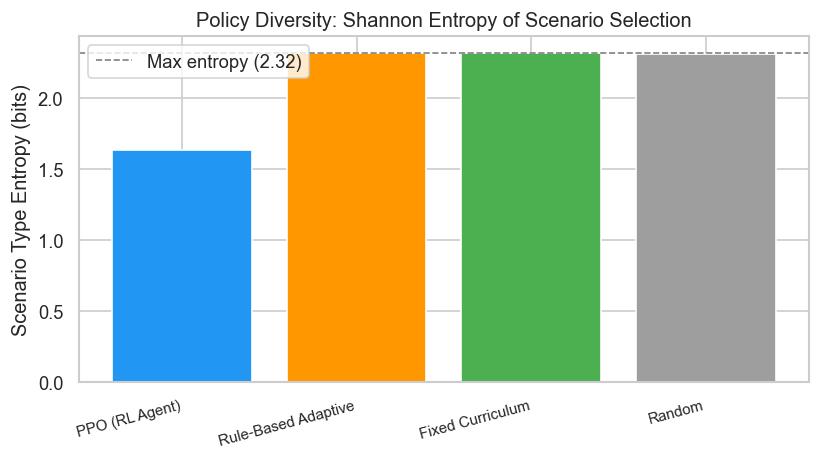

Saved action_diversity.png/.pdf


In [10]:
def shannon_entropy(series):
    """Shannon entropy of a discrete distribution."""
    counts = series.value_counts(normalize=True)
    return float(-np.sum(counts * np.log2(counts + 1e-12)))

entropy_rows = []
for agent in AGENT_ORDER:
    sub = df[df["agent"] == agent]
    h_action   = shannon_entropy(sub["action_idx"])    # full action entropy (max = log2(225) ≈ 7.81)
    h_scenario = shannon_entropy(sub["scenario_type"]) # scenario entropy (max = log2(5) ≈ 2.32)
    entropy_rows.append({"agent": agent, "action_entropy": round(h_action, 3), "scenario_entropy": round(h_scenario, 3)})

entropy_df = pd.DataFrame(entropy_rows).set_index("agent")
max_action_entropy   = np.log2(225)
max_scenario_entropy = np.log2(5)
entropy_df["action_entropy_pct"]   = (entropy_df["action_entropy"]   / max_action_entropy   * 100).round(1)
entropy_df["scenario_entropy_pct"] = (entropy_df["scenario_entropy"] / max_scenario_entropy * 100).round(1)
print(entropy_df.to_string())
entropy_df.to_csv(DATA_DIR / "action_diversity.csv")

# Plot scenario entropy
fig, ax = plt.subplots(figsize=(7, 4))
colors = [AGENT_PALETTE[a] for a in entropy_df.index]
ax.bar(entropy_df.index, entropy_df["scenario_entropy"], color=colors, edgecolor="white")
ax.axhline(max_scenario_entropy, color="grey", linestyle="--", linewidth=1, label=f"Max entropy ({max_scenario_entropy:.2f})")
ax.set_ylabel("Scenario Type Entropy (bits)")
ax.set_title("Policy Diversity: Shannon Entropy of Scenario Selection")
ax.set_xticklabels(entropy_df.index, rotation=15, ha="right", fontsize=9)
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "action_diversity.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "action_diversity.pdf", bbox_inches="tight")
plt.show()
print("Saved action_diversity.png/.pdf")

## 10  Per-Severity Statistical Tests (PPO vs Rule-Based)

In [11]:
print(f"{'Severity':<12} {'PPO mean':>10} {'RB mean':>10} {'Δ':>8} {'p-value':>10} {'d':>8} {'effect':>12}")
print("-" * 70)
sev_stat_rows = []
for sev, sev_label in SEVERITY_LABELS.items():
    ppo_r = ep[(ep["agent"]=="PPO (RL Agent)")      & (ep["severity"]==sev)]["episode_reward"].values
    rb_r  = ep[(ep["agent"]=="Rule-Based Adaptive") & (ep["severity"]==sev)]["episode_reward"].values
    if len(ppo_r) < 2 or len(rb_r) < 2:
        print(f"  {sev_label}: insufficient data")
        continue
    u_stat, p_val = stats.mannwhitneyu(ppo_r, rb_r, alternative="greater")
    d = cohens_d(ppo_r, rb_r)
    print(f"{sev_label:<12} {np.mean(ppo_r):>10.3f} {np.mean(rb_r):>10.3f} {np.mean(ppo_r)-np.mean(rb_r):>+8.3f} {p_val:>10.4f} {d:>8.3f} {effect_label(d):>12}")
    sev_stat_rows.append({
        "severity": sev_label, "ppo_mean": round(float(np.mean(ppo_r)),4),
        "rule_based_mean": round(float(np.mean(rb_r)),4),
        "delta": round(float(np.mean(ppo_r)-np.mean(rb_r)),4),
        "p_value": round(p_val,4), "cohens_d": round(d,4), "effect_size": effect_label(d)
    })

pd.DataFrame(sev_stat_rows).to_csv(DATA_DIR / "severity_statistical_tests.csv", index=False)
print("\nSaved severity_statistical_tests.csv")

Severity       PPO mean    RB mean        Δ    p-value        d       effect
----------------------------------------------------------------------
Mild             14.745     13.614   +1.131     0.0086    1.381        large
Moderate         14.521     12.678   +1.843     0.0000    1.452        large
Severe           11.808     10.889   +0.919     0.0575    0.695       medium

Saved severity_statistical_tests.csv


## 11  Emotional Trajectory Over Episode Steps

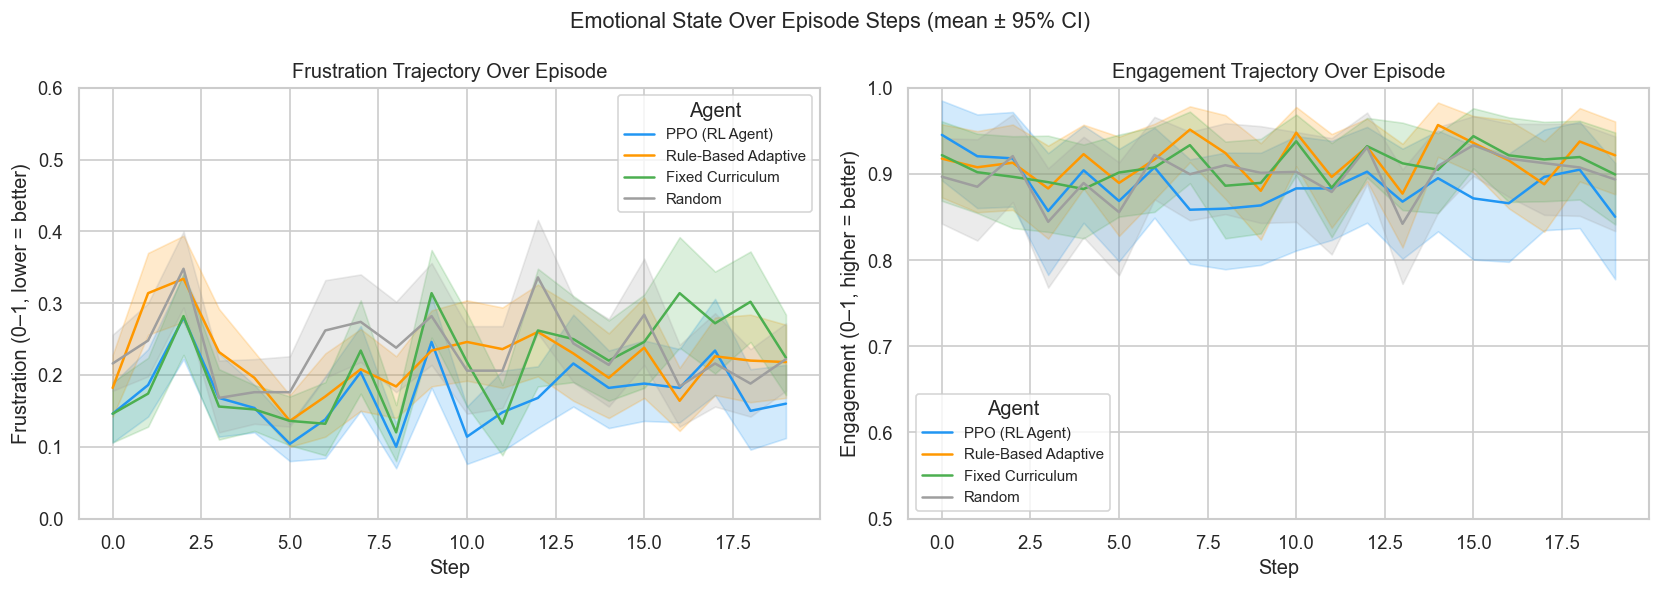

Saved emotional_trajectories.png/.pdf


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Frustration over steps
ax = axes[0]
sns.lineplot(
    data=df, x="step", y="frustration",
    hue="agent", hue_order=AGENT_ORDER,
    palette=AGENT_PALETTE,
    errorbar=("ci", 95), ax=ax,
)
ax.set_xlabel("Step")
ax.set_ylabel("Frustration (0–1, lower = better)")
ax.set_title("Frustration Trajectory Over Episode")
ax.set_ylim(0, 0.6)
ax.legend(title="Agent", fontsize=9)

# Engagement over steps
ax = axes[1]
sns.lineplot(
    data=df, x="step", y="engagement",
    hue="agent", hue_order=AGENT_ORDER,
    palette=AGENT_PALETTE,
    errorbar=("ci", 95), ax=ax,
)
ax.set_xlabel("Step")
ax.set_ylabel("Engagement (0–1, higher = better)")
ax.set_title("Engagement Trajectory Over Episode")
ax.set_ylim(0.5, 1.0)
ax.legend(title="Agent", fontsize=9)

fig.suptitle("Emotional State Over Episode Steps (mean ± 95% CI)", fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "emotional_trajectories.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "emotional_trajectories.pdf", bbox_inches="tight")
plt.show()
print("Saved emotional_trajectories.png/.pdf")

## 12  Key Findings Summary

In [13]:
ppo_mean   = ep[ep["agent"]=="PPO (RL Agent)"]["episode_reward"].mean()
rb_mean    = ep[ep["agent"]=="Rule-Based Adaptive"]["episode_reward"].mean()
rand_mean  = ep[ep["agent"]=="Random"]["episode_reward"].mean()
curr_mean  = ep[ep["agent"]=="Fixed Curriculum"]["episode_reward"].mean()

ppo_frust  = ep[ep["agent"]=="PPO (RL Agent)"]["mean_frustration"].mean()
rb_frust   = ep[ep["agent"]=="Rule-Based Adaptive"]["mean_frustration"].mean()

ppo_sev3   = ep[(ep["agent"]=="PPO (RL Agent)") & (ep["severity"]==3)]["episode_reward"].mean()
rb_sev3    = ep[(ep["agent"]=="Rule-Based Adaptive") & (ep["severity"]==3)]["episode_reward"].mean()

print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)
print(f"\n1. PPO vs Random:          +{(ppo_mean-rand_mean)/rand_mean*100:.1f}% reward")
print(f"   PPO vs Rule-Based:       +{(ppo_mean-rb_mean)/rb_mean*100:.1f}% reward")
print(f"   PPO vs Fixed Curriculum: +{(ppo_mean-curr_mean)/curr_mean*100:.1f}% reward")
print(f"\n2. Frustration reduction vs Rule-Based: {(rb_frust-ppo_frust)/rb_frust*100:.1f}% lower")
print(f"\n3. Severe profile advantage (PPO vs Rule-Based):")
print(f"   PPO={ppo_sev3:.3f}, RB={rb_sev3:.3f}, Δ={ppo_sev3-rb_sev3:+.3f}")
print(f"\n4. Task completion rate:")
for agent in AGENT_ORDER:
    rate = ep[ep["agent"]==agent]["task_rate"].mean()
    print(f"   {agent:<30}: {rate:.3f}")
print("=" * 60)

KEY FINDINGS

1. PPO vs Random:          +14.6% reward
   PPO vs Rule-Based:       +11.5% reward
   PPO vs Fixed Curriculum: +7.5% reward

2. Frustration reduction vs Rule-Based: 21.6% lower

3. Severe profile advantage (PPO vs Rule-Based):
   PPO=11.808, RB=10.889, Δ=+0.919

4. Task completion rate:
   PPO (RL Agent)                : 0.647
   Rule-Based Adaptive           : 0.485
   Fixed Curriculum              : 0.538
   Random                        : 0.464
